In [1]:
import fitz
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

## Extracting data

In [2]:
files = [f.name for f in Path("../resumes/").iterdir() if f.is_file() and "resume" in f.name]

In [3]:
# Function to remove any other special characters which are not used in regular english writing...
def remove_special_chars(text: str) -> str:
    return re.sub(r"[^a-zA-Z0-9\s/,.:;'\"~!@#$%^&*()\[\]{}\\\|_+\-]", "", text)

In [4]:
# Function to extract text from PDF...
def extract_resume_data(file_name):
    doc = fitz.open(f"../resumes/{file_name}")
    result = ""
    for page in doc:
        text = "".join(page.get_text("text"))
        result += text

    # Sanitizing the data..
    result = remove_special_chars(result)
    
    return result

In [5]:
extracted_data = []
for file in tqdm(files):
    extracted_data.append(extract_resume_data(file))

100%|██████████| 600/600 [00:02<00:00, 276.16it/s]


In [6]:
print(extracted_data[5])

Yan Rajan
Jr. Research Data Scientist
+91-7183239375  yanrajan@protonmail.com  Chennai, India  linkedin.com/in/yan-rajan  github.com/yanrajan39
CAREER SUMMARY
Experienced Research Data Scientist skilled in pandas, SQL, and Airflow, with 2+ years delivering predictive models and
data-driven products. Adept at performance optimization, translating ambiguous requirements into reliable, scalable
systems, and driving measurable business impact.
PROFESSIONAL EXPERIENCE
Applied Data Scientist, Wavelengthlabs Technologies
12/2024 to 05/2026
Pune, India
 Partnered with engineering to move models from notebooks to production, reducing scoring latency to under
50ms.
 Reduced forecasting error (MAPE) by 25% using gradient-boosted models and richer feature engineering on A/B
Testing.
 Productionized the recommendation engine that increased click-through rate by 40% and session depth by 98%.
 Built an A/B-testing platform with CUPED and sequential testing, enabling 4+ concurrent experiments and 3x
e

In [7]:
extracted_data_dict = [
    {"resume_text": text} for text in extracted_data
]

In [8]:
df = pd.DataFrame(extracted_data_dict)

In [9]:
print(df['resume_text'].iloc[5])

Yan Rajan
Jr. Research Data Scientist
+91-7183239375  yanrajan@protonmail.com  Chennai, India  linkedin.com/in/yan-rajan  github.com/yanrajan39
CAREER SUMMARY
Experienced Research Data Scientist skilled in pandas, SQL, and Airflow, with 2+ years delivering predictive models and
data-driven products. Adept at performance optimization, translating ambiguous requirements into reliable, scalable
systems, and driving measurable business impact.
PROFESSIONAL EXPERIENCE
Applied Data Scientist, Wavelengthlabs Technologies
12/2024 to 05/2026
Pune, India
 Partnered with engineering to move models from notebooks to production, reducing scoring latency to under
50ms.
 Reduced forecasting error (MAPE) by 25% using gradient-boosted models and richer feature engineering on A/B
Testing.
 Productionized the recommendation engine that increased click-through rate by 40% and session depth by 98%.
 Built an A/B-testing platform with CUPED and sequential testing, enabling 4+ concurrent experiments and 3x
e

In [10]:
df.head()

,resume_text
0,Siddharth Mishra\nStaff Cloud Engineer\nContac...
1,Jun Kumar\nFirmware Engineer\n0151 4722592 ju...
2,James King\nMobile Developer\n+918626791083 j...
3,Sofia Schmidt\nSr. Cybersecurity Engineer\nCon...
4,Lucas Evans\nData Scientist\n(423) 588-3548 ev...


## Analysing the data

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   resume_text  600 non-null    str  
dtypes: str(1)
memory usage: 1.7 MB


In [12]:
resume_lengths = [ len(resume) for resume in df["resume_text"]]
resume_lengths[0]

3332

/var/folders/d8/l1z8x_6j4qv99r7plyccwy0h0000gn/T/ipykernel_21484/3332875012.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(resume_lengths, vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))


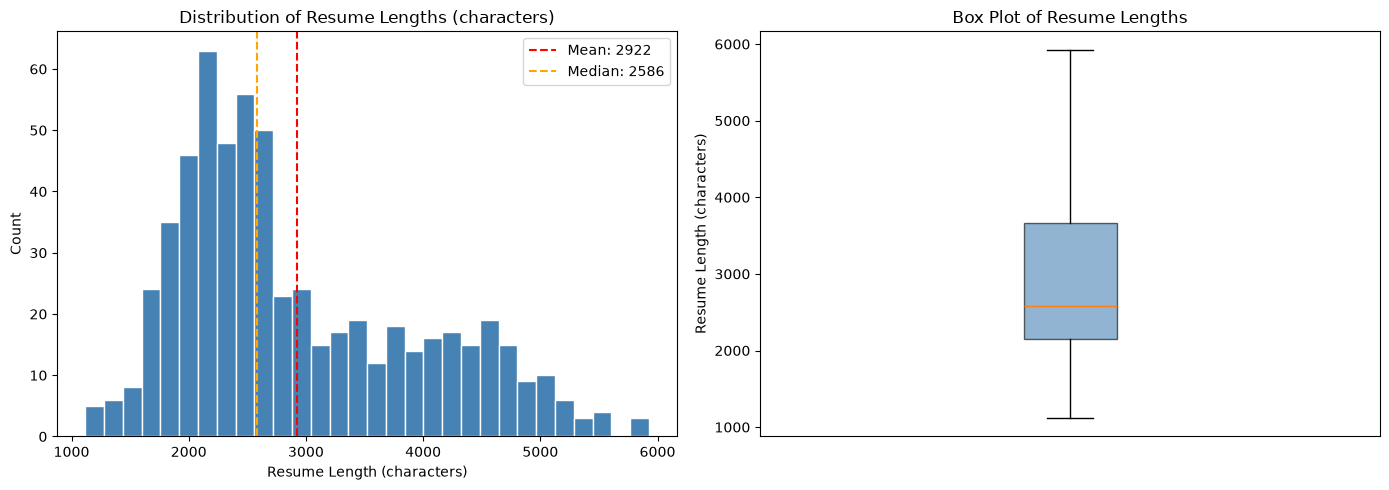

Min:      1118
Max:      5926
Mean:     2922
Median:   2586
Std:      1030


In [13]:
resume_lengths = [len(resume) for resume in df["resume_text"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(resume_lengths, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(np.mean(resume_lengths), color="red", linestyle="--", label=f"Mean: {np.mean(resume_lengths):.0f}")
axes[0].axvline(np.median(resume_lengths), color="orange", linestyle="--", label=f"Median: {np.median(resume_lengths):.0f}")
axes[0].set_title("Distribution of Resume Lengths (characters)")
axes[0].set_xlabel("Resume Length (characters)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].boxplot(resume_lengths, vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Box Plot of Resume Lengths")
axes[1].set_ylabel("Resume Length (characters)")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f"Min:    {min(resume_lengths):>6}")
print(f"Max:    {max(resume_lengths):>6}")
print(f"Mean:   {np.mean(resume_lengths):>6.0f}")
print(f"Median: {np.median(resume_lengths):>6.0f}")
print(f"Std:    {np.std(resume_lengths):>6.0f}")

## Saving the data

In [15]:
SAVE_PATH = "../datasets/"
SAVE_FILE_NAME = "extracted_text_raw_dataset.csv"
df.to_csv(SAVE_PATH+SAVE_FILE_NAME)